In [29]:
#Generate values belonging to 2 classes m and f

import numpy as np

np.random.seed(42)

n = 100

fw = np.random.uniform(45, 75, n)
fh = np.random.uniform(150, 170, n)

mw = np.random.uniform(65, 90, n)
mh = np.random.uniform(160, 190, n)

In [30]:
def plot_wh(fw,fh,mw,mh):
    
    import matplotlib.pyplot as plt
    """
    Plots scatter data for female and male height vs weight.

    Parameters:
    fw : array-like -> female weights
    fh : array-like -> female heights
    mw : array-like -> male weights
    mh : array-like -> male heights
    """

   
    plt.scatter(fw, fh, label="Female", marker = 'o')
    plt.scatter(mw, mh, label="Male", marker = 'x')
    
    plt.xlabel("Weight")
    plt.ylabel("Height")
    plt.legend()
    plt.title("Generated Data")
    plt.show()

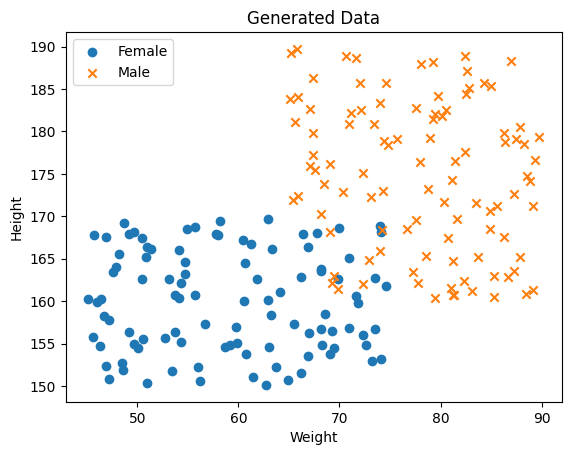

In [31]:
plot_wh(fw, fh, mw, mh)

In [32]:
#Generate a random line - (x2 - w0 - w1x1 = 0)

w0 = 195
w1 = -0.4


In [41]:
def plot_decision_line(w0,w1, fw,fh,mw,mh):
    # Plot female data (fw, fh)
    plt.scatter(fw, fh, label="Female", marker='o')
    
    # Plot male data (mw, mh)
    plt.scatter(mw, mh, label="Male", marker='x')
    
    # Create x values for line
    x_vals = np.linspace(min(fw.min(), mw.min()) - 1,
                         max(fw.max(), mw.max()) + 1, 100)
    
    # Compute y values from line equation
    y_vals = w0 + (w1 * x_vals)
    
    # Plot the line
    plt.plot(x_vals, y_vals, linestyle="--", label="Decision boundary", color = 'green')
    
    # Labels
    plt.xlabel("Weight")
    plt.ylabel("Height")
    plt.title("Scatter Plot with Decision Boundary")
    
    plt.legend()
    plt.grid(True)
    plt.show()

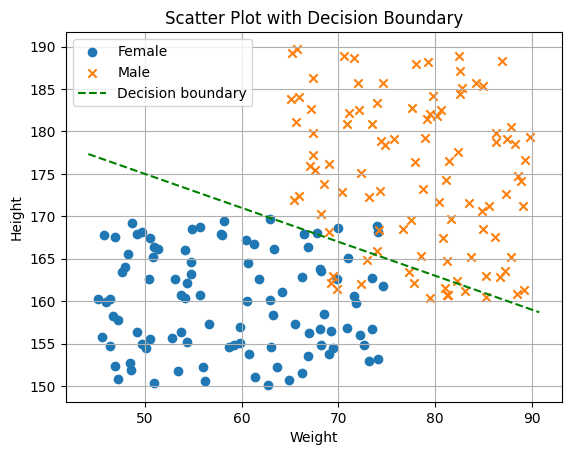

In [42]:
plot_decision_line(w0,w1, fw,fh,mw,mh)

In [58]:
def classify_fm(fw,fh,mw,mh,w0,w1):
    #Generate classes for the data
    
    # Combine data
    x1 = np.concatenate((fw, mw))  # weight
    x2 = np.concatenate((fh, mh))  # height
    
    # Labels:  1 = female, 0 = male
    y_true = np.concatenate((np.ones(n), np.zeros(n)))

    #Compute scores for points with respect to line 

    score = x2 - w0 - (w1*x1)
    
    y_pred= []
    for i in score:
        if i > 0:
            y_pred.append(0)
        else: 
            y_pred.append(1)
        
    
    y_pred = np.array(y_pred)
    
    
    # Correct classifications
    correct = y_pred == y_true

    return correct


In [59]:
classify_fm(fw,fh,mw,mh,w0,w1)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [47]:
def plot_classification(y_true, y_pred):
    # Misclassification breakdown
    male_mis = (y_true == 0) & (y_pred == 1)
    female_mis = (y_true == 1) & (y_pred == 0)
    
    # ---- Plot ----
    plt.figure(figsize=(8,6))
    
    # Correct points
    plt.scatter(x1[(y_true == 1) & correct],
                x2[(y_true == 1) & correct],
                marker='o', label='Female (Correct)', alpha=0.7)
    
    plt.scatter(x1[(y_true == 0) & correct],
                x2[(y_true == 0) & correct],
                marker='x',label='Male (Correct)', alpha=0.7)
    
    # Misclassified points
    plt.scatter(x1[female_mis], x2[female_mis],
                color='red', marker='x',
                label='Female → Predicted Male', zorder=3)
    
    plt.scatter(x1[male_mis], x2[male_mis],
                color='red', marker='o',
                label='Male → Predicted Female', zorder=3)
    
    # Decision boundary
    plt.plot(x_vals, y_vals, linestyle="--", label="Decision boundary", color = 'green')
    
    
    # Labels and styling
    plt.xlabel("Weight")
    plt.ylabel("Height")
    plt.title("Scatter Plot with Decision Boundary & Misclassifications")
    plt.legend()
    plt.grid(True)

    plt.show()

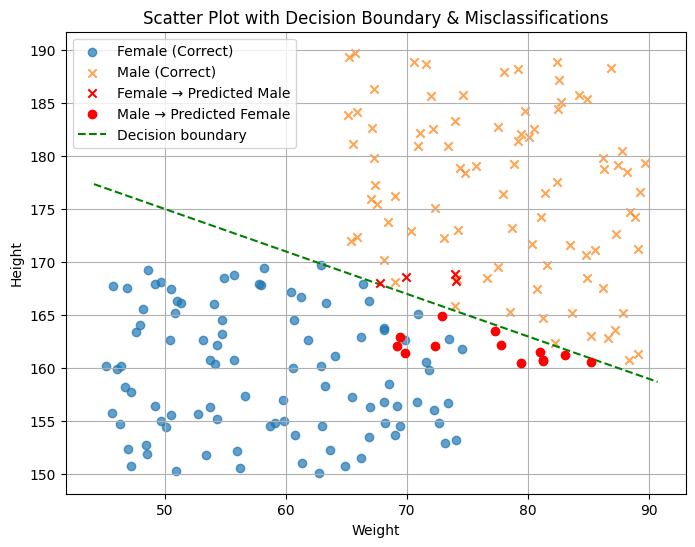

In [48]:
plot_classification(y_true,y_pred)

In [49]:
def accuracy_percent(pred, true):
    accuracy_percent = np.mean(pred == true) * 100
    print("Accuracy (%):", accuracy_percent)

In [50]:
accuracy_percent(y_pred, y_true)

Accuracy (%): 91.5


In [55]:
def true_matrix(y_true,y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    matrix = np.array([[tn,fp], [fn,tp]])

    return matrix

      

In [56]:
true_matrix(y_true,y_pred)

array([[87, 13],
       [ 4, 96]])